# JOUR8500 Week07 Multimodal Analysis (Face++ API & DeepFace) (with answer)
Jiakun Liang, Jiarou Chen, Jikai Sun

2026-03-05

# Introduction

### 1. Tasks of automated content analysis of images (Williams et al., 2020)

*   Object recognition
*   Facial Recognition, Analysis, and Detection
*   Visual Sentiment Analysis and Affect: emotion being expressed by people in an image - lower accuracy compared to the previous two tasks

### 2. Why do we need to analyze people’s facial images?

*   Compared to text, images are more universal and can convey implicit information, such as emotions and identities, that are difficult to quantify manually.

### 3. Basic workflow

*   images -> numerical features -> further interpretation and/or analysis

### 4. The tools we cover today

*   Face++: commercial API
*   DeepFace: open-source library

### 5. The analysis involved today

*   Face counting: Face++
*   Face analysis: demographic information; emotions: Face++ & DeepFace


In [ ]:
# import external libraries and modules required for the subsequent program
import requests
import json
import os
import pandas as pd
from google.colab import drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Face++


## Step 1: Face++ setup

First, we need to set up parameters we get from Megvil.


In [ ]:
import requests
import os
import time
from PIL import Image # For image resizing
import io # For in-memory image handling


# Settings
FOLDER_PATH = "/content/drive/MyDrive/JOUR_8500_demo_Face/FacePlusImage/"
# We have 12 images in the file FacePlusImage uploaded on Google Drive
API_KEY = "gWqGb0QoOaQDLQ3ZXBjYxixZjNCPlmuf"
API_SECRET = "gQj43oTjV04eqYqz4PZqdWslqFHdfD1B"
API_URL = "https://api-us.faceplusplus.com/facepp/v3/detect"

## Step 2: Face++ analysis



*   With a Free API Key, only the 5 largest faces by its bounding box size can be analyzed, while you can use Face Analyze API to analyze the rest faces. With a Standard API Key, you can analyze all the detected faces.
*   Image Requirements


1.   Format: JPG (JPEG), PNG
2.   Size : between 48*48 and 4096*4096 (pixels)
3.   File size: no larger than 2MB

*   Minimal size of face: the bounding box of a detected face is a square. The minimal side length of a square should be no less than 1/48 of the short side of image, and no less than 48 pixels. For example if the size of image is 4096 * 3200px, the minimal size of face should be 66 * 66px.


Counting the number of faces in each image

In [ ]:
# Define the function
# 1. Filter all images in the folder; 2. Resize the images; 3. Send request; 4. Get results
def face_detect_folder(folder):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for filename in files:
        path = os.path.join(folder, filename)

        # Resize
        with Image.open(path) as img:
            img = img.convert("RGB")
            img.thumbnail((1024, 1024)) # Maintain aspect ratio automatically
            buf = io.BytesIO() # "Store" the resized images
            img.save(buf, format='JPEG', quality=85)
            img_data = buf.getvalue()

        # API Request
        params = {
            "api_key": API_KEY,
            "api_secret": API_SECRET,
            "return_landmark": 0 # no need for facial features and contour
            }
        res = requests.post(API_URL, data=params, files={"image_file": img_data}).json()

        # Output
        faces = res.get("faces", [])
        print(f"Done: {len(faces)} faces in {filename}")

        time.sleep(1) # Cooldown for API limits

# Run
face_detect_folder(FOLDER_PATH)

Done: 3 faces in 1.jpg
Done: 1 faces in 2.jpg
Done: 2 faces in 3.jpg
Done: 3 faces in 4.jpg
Done: 1 faces in 5.jpg
Done: 1 faces in 6.jpg
Done: 1 faces in 7.jpg
Done: 1 faces in 8.jpg
Done: 4 faces in 9.jpg
Done: 3 faces in 10.jpg
Done: 1 faces in 11.jpg
Done: 1 faces in 12.jpg


Attribute Analysis per face in every image

In [ ]:
import pandas as pd, time

def analyze_all_images(folder):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    # Create an empty list for storing the results
    all_results = []

    for filename in files:
        path = os.path.join(folder, filename)
        with Image.open(path) as img:
            img = img.convert("RGB"); img.thumbnail((1024, 1024))
            buf = io.BytesIO(); img.save(buf, format='JPEG', quality=85)
            img_data = buf.getvalue()

        params = {
            "api_key": API_KEY,
            "api_secret": API_SECRET,
            "return_attributes": "gender,age,emotion" # the attributes we care about
        }
        res = requests.post(API_URL, data=params, files={"image_file": img_data}).json()

        for face in res.get("faces", []):
            attr = face["attributes"]
            emo = attr["emotion"] # Sum(anger; disgust; fear; happiness; neutral; sadness; surprise) = 100
            all_results.append({
                "Filename": filename,
                "Gender": attr["gender"]["value"],
                "Age": attr["age"]["value"],
                "Dominant_Emotion": max(emo, key=emo.get) # Select the emotion with highest score
            })

        print(f"Processed: {filename}")
        time.sleep(1) # API Rate limit

    return pd.DataFrame(all_results)

# Run
df_faces = analyze_all_images(FOLDER_PATH)
display(df_faces.head())

Processed: 1.jpg
Processed: 2.jpg
Processed: 3.jpg
Processed: 4.jpg
Processed: 5.jpg
Processed: 6.jpg
Processed: 7.jpg
Processed: 8.jpg
Processed: 9.jpg
Processed: 10.jpg
Processed: 11.jpg
Processed: 12.jpg


,Filename,Gender,Age,Dominant_Emotion
0,1.jpg,Female,41,happiness
1,1.jpg,Female,25,happiness
2,1.jpg,Male,29,disgust
3,2.jpg,Female,58,sadness
4,3.jpg,Female,29,happiness


## Step 3: Save results

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/JOUR_8500_demo_Face/face_analysis_results.csv"
df_faces.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')

## Exercise

Write a function to extract the "Happiness" score from a specific image's response.


In [ ]:
def get_happiness_from_image(folder, filename):
    path = os.path.join(folder, filename)

    with Image.open(path) as img:
        img = img.convert("RGB")
        img.thumbnail((1024, 1024))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=85)
        img_data = buf.getvalue()

    params = {
        "api_key": API_KEY,
        "api_secret": API_SECRET,
        "return_attributes": "emotion"
    }

    res = requests.post(API_URL, data=params, files={"image_file": img_data}).json()

    for i, face in enumerate(res.get("faces", [])):
        happiness = face["attributes"]["emotion"]["happiness"]
        print(f"Face {i} Happiness score: {happiness}")

get_happiness_from_image(FOLDER_PATH, "3.jpg")

Face 0 Happiness score: 99.957
Face 1 Happiness score: 99.886


# Deepface

**Goal:** Compare the cloud-based API (Face++) with a local library (DeepFace).

**Content:**

*   Introduction to reticulate (running Python's DeepFace within R).
*   Feature comparison: Cost, Privacy, Speed, and Accuracy.


## Step 1: Deepface setup

In [ ]:
!pip install deepface tf-keras opencv-python -q

In [ ]:
import requests
import json
import os
import pandas as pd
from google.colab import drive
from PIL import Image
import io
import time
from deepface import DeepFace

## Step 2: Deepface analysis

In [ ]:
def count_faces(image_path):
    try:
        faces = DeepFace.extract_faces(
            img_path=image_path,
            enforce_detection=False
        )
        return len(faces)
    except:
        return 0


all_files = [
    f for f in os.listdir(FOLDER_PATH)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

face_count_results = []

print(f"Starting face counting for {len(all_files)} images")

for filename in all_files:
    full_path = os.path.join(FOLDER_PATH, filename)
    num_faces = count_faces(full_path)

    face_count_results.append({
        "Filename": filename,
        "Face_Count": num_faces
    })

    print(f"{filename}: {num_faces} face(s)")
    time.sleep(0.5)

df_count = pd.DataFrame(face_count_results)
df_count.to_csv("face_count_summary.csv", index=False)

print("\nFace count summary saved.")


# Attribute analysis per face

def analyze_all_faces(image_path):
    filename = os.path.basename(image_path)
    results = []

    try:
        objs = DeepFace.analyze(
            img_path=image_path,
            actions=['age', 'gender', 'race', 'emotion'],
            enforce_detection=False,
            silent=True
        )

        for i, face_data in enumerate(objs, start=1):

            result_entry = {
                "Filename": filename,
                "Face_Index": i,
                "Age": face_data["age"],
                "Gender": face_data["dominant_gender"],
                "Race": face_data["dominant_race"],
                "Emotion": face_data["dominant_emotion"]
            }

            results.append(result_entry)

    except Exception as e:
        results.append({
            "Filename": filename,
            "Face_Index": None,
            "Error": str(e)
        })

    return results


all_face_results = []

print("\nStarting attribute analysis")

for filename in all_files:
    full_path = os.path.join(FOLDER_PATH, filename)

    face_results = analyze_all_faces(full_path)

    all_face_results.extend(face_results)

    print(f"{filename}: {len(face_results)} analyzed")
    time.sleep(1)

df_faces_d = pd.DataFrame(all_face_results)

Starting face counting for 12 images
1.jpg: 3 face(s)
2.jpg: 1 face(s)
3.jpg: 6 face(s)
4.jpg: 10 face(s)
5.jpg: 1 face(s)
6.jpg: 1 face(s)
7.jpg: 3 face(s)
8.jpg: 3 face(s)
9.jpg: 3 face(s)
10.jpg: 15 face(s)
11.jpg: 1 face(s)
12.jpg: 7 face(s)

Face count summary saved.

Starting attribute analysis
1.jpg: 3 analyzed
2.jpg: 1 analyzed
3.jpg: 6 analyzed
4.jpg: 10 analyzed
5.jpg: 1 analyzed
6.jpg: 1 analyzed
7.jpg: 3 analyzed
8.jpg: 3 analyzed
9.jpg: 3 analyzed
10.jpg: 15 analyzed
11.jpg: 1 analyzed
12.jpg: 7 analyzed


## Step 3: Save results

In [ ]:
SAVE_PATH_2 = "/content/drive/MyDrive/JOUR_8500_demo_Face/face_analysis_results_DF.csv"
df_faces_d.to_csv(SAVE_PATH_2, index=False, encoding='utf-8-sig')

print("\nAttribute analysis saved.")
print(df_faces_d.head())


Attribute analysis saved.
  Filename  Face_Index  Age Gender             Race  Emotion
0    1.jpg           1   27  Woman            white    happy
1    1.jpg           2   34    Man            white    happy
2    1.jpg           3   29  Woman            asian  neutral
3    2.jpg           1   28    Man            asian      sad
4    3.jpg           1   27  Woman  latino hispanic    happy


## Exercise:

Run the DeepFace.analyze() command to detect the age of Sunak (Sunak.png) in the PMImage file, and compare the results with the prediction by Face++.


In [ ]:
# DeepFace
# Setting:
FOLDER_PATH_EXER = "/content/drive/MyDrive/JOUR_8500_demo_Face/PMImage/"
image_file_exer = "Sunak.png"
image_path = os.path.join(FOLDER_PATH_EXER, image_file_exer)

# Count Analysis:
def count_faces(image_path):
    try:
        faces = DeepFace.extract_faces(
            img_path=image_path,
            enforce_detection=False
        )
        return len(faces)
    except Exception as e:
        print("Error:", e)
        return 0

num_faces = count_faces(image_path)
print(f"{image_file_exer}: {num_faces} face(s)")

# Attribute Analysis
def analyze_face_age(image_path):
    filename = os.path.basename(image_path)

    try:
        objs = DeepFace.analyze(
            img_path=image_path,
            actions=['age'],
            enforce_detection=False,
            silent=True
        )

        # DeepFace may return a dict (single face) or a list (multiple faces)
        if isinstance(objs, dict):
            objs = [objs]

        results = []
        for i, face_data in enumerate(objs, start=1):
            results.append({
                "Filename": filename,
                "Face_Index": i,
                "Age": face_data.get("age", None)
            })

        # If still empty, return a diagnostic row (so you see something)
        if len(results) == 0:
            results.append({
                "Filename": filename,
                "Face_Index": None,
                "Error": "No face results returned by DeepFace (objs was empty)."
            })

        return results

    except Exception as e:
        return [{
            "Filename": filename,
            "Face_Index": None,
            "Error": str(e)
        }]

sunak_results = analyze_face_age(image_path)
df_faces_d = pd.DataFrame(sunak_results)
display(df_faces_d)

# Face++
# Setting:
FOLDER_PATH_EXER = "/content/drive/MyDrive/JOUR_8500_demo_Face/PMImage/"
filename = "Sunak.png"
path = os.path.join(FOLDER_PATH_EXER, filename)

# Count Analysis
def face_detect_one_image(image_path, filename):
    # Resize (same as your original code)
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img.thumbnail((1024, 1024))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=85)
        img_data = buf.getvalue()

    # Face++ API Request
    params = {
        "api_key": API_KEY,
        "api_secret": API_SECRET,
        "return_landmark": 0
    }

    res = requests.post(API_URL, data=params, files={"image_file": img_data}).json()

    faces = res.get("faces", [])
    print(f"Done: {len(faces)} faces in {filename}")

    # (Optional) Print full response if no faces or error
    if "error_message" in res:
        print("Face++ error:", res["error_message"])

    return res

# Run on Sunak.png
res_sunak = face_detect_one_image(path, filename)

# Age Analysis
def analyze_one_image_age(image_path, filename):
    # preprocess image (same as your pipeline)
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img.thumbnail((1024, 1024))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=85)
        img_data = buf.getvalue()

    # Face++ request: only ask for age (minimal)
    params = {
        "api_key": API_KEY,
        "api_secret": API_SECRET,
        "return_attributes": "age"
    }

    res = requests.post(API_URL, data=params, files={"image_file": img_data}).json()

    # If Face++ returns an error, print it
    if "error_message" in res:
        print("Face++ error:", res["error_message"])
        return pd.DataFrame([{"Filename": filename, "Error": res["error_message"]}])

    # Extract age(s)
    results = []
    for i, face in enumerate(res.get("faces", []), start=1):
        age = face["attributes"]["age"]["value"]
        results.append({
            "Filename": filename,
            "Face_Index": i,
            "Age": age
        })

    # If no face detected
    if not results:
        results.append({"Filename": filename, "Face_Index": None, "Age": None})

    return pd.DataFrame(results)

# Run
df_sunak_age = analyze_one_image_age(path, filename)
display(df_sunak_age)

Sunak.png: 2 face(s)


,Filename,Face_Index,Age
0,Sunak.png,1,24
1,Sunak.png,2,32


Done: 1 faces in Sunak.png


,Filename,Face_Index,Age
0,Sunak.png,1,36


Answer: Two faces with the ages of 24 and 32 are detected by DeepFace, whereas Face++ detects one face with the age of 36. From Wikipedia, we know Sunak is 45 years old, so both models produce the inaccurate and inconsistent results, suggesting the limitations of the automated visual analysis.

## Step4: Deepface Analysis-Face embeddings

Total detected faces: 54
Selected faces:
12.jpg Face 2
4.jpg Face 3
Cosine Similarity: 0.6071527716704564


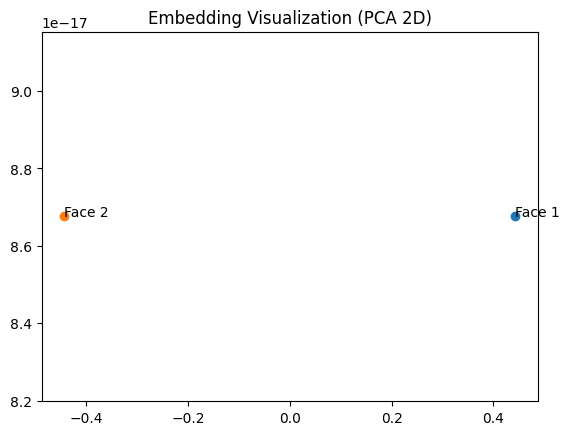

In [ ]:
FOLDER_PATH = "/content/drive/MyDrive/JOUR_8500_demo_Face/FacePlusImage/"
# New code (Face embeddings and similarities)

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from numpy.linalg import norm
from sklearn.decomposition import PCA
from deepface import DeepFace



def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))


# Step 1: Extract all embeddings from folder
def collect_all_embeddings(folder_path):
    embeddings_list = []

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for filename in image_files:
        full_path = os.path.join(folder_path, filename)

        try:
            embedding_objs: List[dict] = DeepFace.represent(
                img_path=full_path,
                model_name="VGG-Face",
                enforce_detection=False
            )

            for idx, obj in enumerate(embedding_objs):
                embeddings_list.append({
                    "Filename": filename,
                    "Face_Index": idx,
                    "Embedding": obj["embedding"]
                })

        except Exception as e:
            print(f"Skipping {filename} due to error: {e}")

    return embeddings_list


all_embeddings = collect_all_embeddings(FOLDER_PATH)

print("Total detected faces:", len(all_embeddings))


# Step 2: Check if enough faces exist
if len(all_embeddings) < 2:
    print("At least two faces are required for similarity comparison.")
else:
    # Step 3: Randomly select two faces
    face1, face2 = random.sample(all_embeddings, 2)

    vec1 = np.array(face1["Embedding"])
    vec2 = np.array(face2["Embedding"])

    print("Selected faces:")
    print(face1["Filename"], "Face", face1["Face_Index"])
    print(face2["Filename"], "Face", face2["Face_Index"])

    # Step 4: Compute similarity
    similarity_score = cosine_similarity(vec1, vec2)
    print("Cosine Similarity:", similarity_score)

    # Step 5: PCA visualization
    embeddings_matrix = np.vstack([vec1, vec2])

    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings_matrix)

    plt.figure()
    plt.scatter(embeddings_2d[0, 0], embeddings_2d[0, 1])
    plt.scatter(embeddings_2d[1, 0], embeddings_2d[1, 1])

    plt.text(embeddings_2d[0, 0], embeddings_2d[0, 1], "Face 1")
    plt.text(embeddings_2d[1, 0], embeddings_2d[1, 1], "Face 2")

    plt.title("Embedding Visualization (PCA 2D)")
    plt.show()

## Exercise

Write the cosine_similarity function to detect which two faces in the dataset have the highest cosine similarity.

In [ ]:
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))

def collect_all_embeddings(folder_path):
    embeddings_list = []
    image_files = [f for f in os.listdir(folder_path)
                   if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    for filename in image_files:
        full_path = os.path.join(folder_path, filename)
        try:
            embedding_objs: List[dict] = DeepFace.represent(
                img_path=full_path,
                model_name="VGG-Face",
                enforce_detection=False
            )
            for idx, obj in enumerate(embedding_objs):
                embeddings_list.append({
                    "Filename": filename,
                    "Face_Index": idx,
                    "Embedding": obj["embedding"]
                })
        except Exception as e:
            print(f"Skipping {filename} due to error: {e}")

    return embeddings_list

# 1) Extract embeddings
all_embeddings = collect_all_embeddings(FOLDER_PATH)
print("Total detected faces:", len(all_embeddings))

# 2) Compute ALL pairwise similarity scores
pairs = []
n = len(all_embeddings)

if n < 2:
    print("At least two faces are required for similarity comparison.")
else:
    for i in range(n):
        vec_i = np.array(all_embeddings[i]["Embedding"])
        for j in range(i + 1, n):
            vec_j = np.array(all_embeddings[j]["Embedding"])
            score = cosine_similarity(vec_i, vec_j)

            pairs.append({
                "Face1_Filename": all_embeddings[i]["Filename"],
                "Face1_Index": all_embeddings[i]["Face_Index"],
                "Face2_Filename": all_embeddings[j]["Filename"],
                "Face2_Index": all_embeddings[j]["Face_Index"],
                "Cosine_Similarity": score
            })

    df_sims = pd.DataFrame(pairs)
    df_sims_sorted = df_sims.sort_values("Cosine_Similarity", ascending=False)


    # Show top rows
    display(df_sims_sorted.head(20))

Total detected faces: 54


,Face1_Filename,Face1_Index,Face2_Filename,Face2_Index,Cosine_Similarity
966,7.jpg,1,7.jpg,2,0.926202
1428,12.jpg,4,12.jpg,5,0.908672
612,4.jpg,3,4.jpg,5,0.892928
1429,12.jpg,4,12.jpg,6,0.886084
1422,12.jpg,2,12.jpg,4,0.884697
655,4.jpg,4,4.jpg,9,0.875042
977,7.jpg,1,10.jpg,4,0.867418
1006,7.jpg,2,10.jpg,4,0.847783
1430,12.jpg,5,12.jpg,6,0.842456
1424,12.jpg,2,12.jpg,6,0.842060


## Reference

Williams, N. W., Casas, A., & Wilkerson, J. D. (2020). *Images as data for social science research : An introduction to convolutional neural nets for image classification.* Cambridge University Press.